In [72]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)

if torch.cuda.is_available():
    major, minor = torch.cuda.get_device_capability()
    print(f"Compute Capability: {major}.{minor}")
    if major >= 8:
        print("✅ TF32 is supported (Ampere or newer).")
    else:
        print("❌ TF32 is not supported.")

Using device: cuda
Compute Capability: 8.6
✅ TF32 is supported (Ampere or newer).


In [73]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

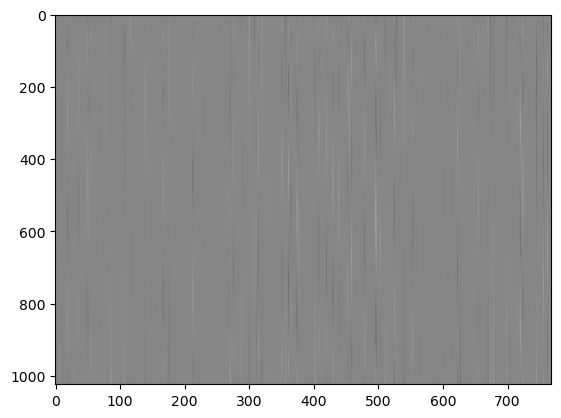

In [74]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.imshow(sd_hf['transformer.wpe.weight'].numpy(), cmap='gray', aspect='auto')


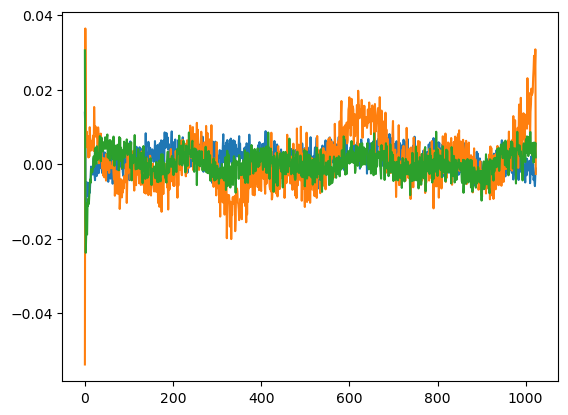

In [75]:
plt.plot(sd_hf['transformer.wpe.weight'][:, 100], label='wpe')
plt.plot(sd_hf['transformer.wpe.weight'][:, 200], label='wpe')
plt.plot(sd_hf['transformer.wpe.weight'][:, 500], label='wpe')

In [76]:
from transformers import pipeline, set_seed
hf_generator = pipeline('text-generation', model='gpt2')

Device set to use cuda:0


In [77]:
from dataclasses import dataclass
import torch.nn as nn
from torch.nn import functional as F

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1
        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side
        # output projection
        y = self.c_proj(y)
        return y
    
class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu = nn.GELU(approximate='tanh')
        self.c_proj = nn.Linear(4 * config.n_embd, config.n_embd)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))[0]
        x = x + self.mlp(self.ln_2(x))
        return x


@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 50257
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768


class GPT(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict({
            'wte': nn.Embedding(config.vocab_size, config.n_embd),
            'wpe': nn.Embedding(config.block_size, config.n_embd),
            'h': nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            'ln_f': nn.LayerNorm(config.n_embd)
        })
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Weight sharing scheme: tie the input and output embeddings
        # This is a common technique in transformer models to reduce the number of parameters
        # and improve performance. The output layer is initialized with the same weights as the input layer.
        self.transformer.wte.weight = self.lm_head.weight

        # Initialize weights using the same method as in the original GPT-2 paper
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is shape (B, T) where B is batch size and T is sequence length
        B, T = idx.size()
        # forward the GPT model
        position_ids = torch.arange(T, dtype=torch.long, device=idx.device)
        token_embeddings = self.transformer.wte(idx)
        pos_embeddings = self.transformer.wpe(position_ids)
        x = token_embeddings + pos_embeddings
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x) # (B, T, vocab_size)
        # logits is shape (B, T, vocab_size) where vocab_size is the number of tokens in the vocabulary
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.shape[-1]), # (B*T, vocab_size)
                targets.view(-1)) # (B*T,)
        return logits, loss


    @classmethod
    def from_pretrained(cls, model_type):
        """Loads pretrained GPT-2 model weights from huggingface"""
        assert model_type in {'gpt2', 'gpt2-medium', 'gpt2-large', 'gpt2-xl'}
        from transformers import GPT2LMHeadModel
        print("loading weights from pretrained gpt: %s" % model_type)

        # n_layer, n_head and n_embd are determined from model_type
        config_args = {
            'gpt2':         dict(n_layer=12, n_head=12, n_embd=768),  # 124M params
            'gpt2-medium':  dict(n_layer=24, n_head=16, n_embd=1024), # 350M params
            'gpt2-large':   dict(n_layer=36, n_head=20, n_embd=1280), # 774M params
            'gpt2-xl':      dict(n_layer=48, n_head=25, n_embd=1600), # 1558M params
        }[model_type]
        config_args['vocab_size'] = 50257 # always 50257 for GPT model checkpoints
        config_args['block_size'] = 1024 # always 1024 for GPT model checkpoints
        # create a from-scratch initialized minGPT model
        config = GPTConfig(**config_args)
        model = GPT(config)
        sd = model.state_dict()
        sd_keys = sd.keys()
        sd_keys = [k for k in sd_keys if not k.endswith('.attn.bias')] # discard this mask / buffer, not a param

        # for k in sd_keys:
        #     print(k, sd[k].shape)

        # init a huggingface/transformers model
        model_hf = GPT2LMHeadModel.from_pretrained(model_type)
        sd_hf = model_hf.state_dict()

        # copy while ensuring all of the parameters are aligned and match in names and shapes
        sd_keys_hf = sd_hf.keys()
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.masked_bias')] # ignore these, just a buffer
        sd_keys_hf = [k for k in sd_keys_hf if not k.endswith('.attn.bias')] # same, just the mask (buffer)
        transposed = ['attn.c_attn.weight', 'attn.c_proj.weight', 'mlp.c_fc.weight', 'mlp.c_proj.weight']
        # basically the openai checkpoints use a "Conv1D" module, but we only want to use a vanilla Linear
        # this means that we have to transpose these weights when we import them
        assert len(sd_keys_hf) == len(sd_keys), f"mismatched keys: {len(sd_keys_hf)} != {len(sd_keys)}"
        for k in sd_keys_hf:
            # print(k, sd_hf[k].shape)
            if any(k.endswith(w) for w in transposed):
                # special treatment for the Conv1D weights we need to transpose
                assert sd_hf[k].shape[::-1] == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k].t())
            else:
                # vanilla copy over the other parameters
                assert sd_hf[k].shape == sd[k].shape
                with torch.no_grad():
                    sd[k].copy_(sd_hf[k])

        return model

In [ ]:
import tiktoken

class DataLoaderLite:
    def __init__(self, B, T):
        self.B = B
        self.T = T

        with open('data/tiny_shakespeare.txt', 'r') as f:
            text = f.read()
        enc = tiktoken.get_encoding("gpt2")
        tokens = enc.encode(text)
        self.tokens = torch.tensor(tokens)
        print(f"Loaded {len(self.tokens)} tokens")
        print(f"1 epoch = {len(self.tokens) // (B*T)} batches")
        self.current_position = 0
    
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position:self.current_position + B*T + 1]
        x = buf[:-1].view(B, T)
        y = buf[1:].view(B, T)
        self.current_position += B*T
        if self.current_position + B*T + 1 > len(self.tokens):
            self.current_position = 0
        return x, y

In [ ]:
# model = GPT.from_pretrained('gpt2')
# print('\nSuccessfully Loaded model')
model = GPT(GPTConfig())
model.to(device)
model = torch.compile(model)

GPT(
  (transformer): ModuleDict(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (h): ModuleList(
      (0-11): 12 x Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): CausalSelfAttention(
          (c_attn): Linear(in_features=768, out_features=2304, bias=True)
          (c_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (gelu): GELU(approximate='tanh')
          (c_proj): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [ ]:
import time

# Starting loss should be -log(1/vocab_size) = -log(1/50257) = 10.8

train_loader = DataLoaderLite(B=4, T=1024)
torch.set_float32_matmul_precision('high')
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

for i in range(50):
    t0 = time.time()

    # Start of the training step
    x, y = train_loader.next_batch()
    x = x.to(device)
    y = y.to(device)
    
    optimizer.zero_grad()

    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        # Forward pass
        logits, loss = model(x, y)
    
    loss.backward()
    optimizer.step()
    torch.cuda.synchronize()

    # End of the training step
    t1 = time.time()
    dt = (t1 - t0) * 1e3
    tokens_per_second = (train_loader.B * train_loader.T) / (dt / 1e3)
    print(f"step {i}: loss {loss.item()}, dt: {dt:.2f}ms, TPS: {tokens_per_second:.2f}")


Loaded 338025 tokens
1 epoch = 82 batches
step 0: loss 10.962844848632812, dt: 3212.03ms, TPS: 1275.21
step 1: loss 9.44253158569336, dt: 3339.96ms, TPS: 1226.36
step 2: loss 9.326255798339844, dt: 2541.26ms, TPS: 1611.80
step 3: loss 8.684364318847656, dt: 2588.42ms, TPS: 1582.43
step 4: loss 8.461433410644531, dt: 2578.09ms, TPS: 1588.77
step 5: loss 8.036108016967773, dt: 2501.26ms, TPS: 1637.57
step 6: loss 7.913478851318359, dt: 2665.68ms, TPS: 1536.57
step 7: loss 7.722686767578125, dt: 2793.59ms, TPS: 1466.21
step 8: loss 7.6360931396484375, dt: 2859.70ms, TPS: 1432.32
step 9: loss 7.3238677978515625, dt: 2837.49ms, TPS: 1443.53
step 10: loss 7.3488922119140625, dt: 2957.92ms, TPS: 1384.76
step 11: loss 7.355690002441406, dt: 2928.36ms, TPS: 1398.74
step 12: loss 7.416782379150391, dt: 2518.98ms, TPS: 1626.05
step 13: loss 7.310857772827148, dt: 2933.01ms, TPS: 1396.52
step 14: loss 6.948640823364258, dt: 3009.02ms, TPS: 1361.24
step 15: loss 6.942609786987305, dt: 3895.87ms, TP

In [ ]:
# Generation
enc = tiktoken.get_encoding("gpt2")

def generate(S, num_return_sequences=5, max_length=30):
    model.eval()
    tokens = enc.encode(S)
    tokens = torch.tensor(tokens, device=device)
    x = tokens.unsqueeze(0).repeat(num_return_sequences, 1) # (num_return_sequences, T)

    # Genereate
    while x.shape[1] < max_length:
        with torch.no_grad():
            logits, _ = model(x) # (B, T, vocab_size)
            logits = logits[:, -1, :] # (B, vocab_size)
            probs = F.softmax(logits, dim=-1) # (B, vocab_size)
            tpok_probs, topk_indices = torch.topk(probs, k=5, dim=-1) # (B, 5)
            ix = torch.multinomial(tpok_probs, num_samples=1)
            xcol = topk_indices.gather(-1, ix)
            x = torch.cat((x, xcol), dim=1)
    out = []
    for i in range(num_return_sequences):
        # print(x[i, :max_length])
        out.append(enc.decode(x[i, :max_length].tolist()))
    return out

In [ ]:
num_return_sequences = 5
max_length = 30
S = "Hello, I'm a language model,"

print(f"----------------------------")
print("Using GPT")
print(f"----------------------------")
out = generate(S)
for i, generated_text in enumerate(out):
    print(f"({i}): {generated_text}")

print(f"----------------------------")
print("Using huggingface pipeline")
print(f"----------------------------")
out = hf_generator(S, max_length=max_length, num_return_sequences=num_return_sequences, truncation=True, pad_token_id=hf_generator.tokenizer.eos_token_id)
for i, generated_text in enumerate(out):
    print(f"({i}): {generated_text['generated_text']}")

----------------------------
Using GPT
----------------------------
(0): Hello, I'm a language model,

.
.
 the
,



:


,

,,
(1): Hello, I'm a language model,,

 the
.

 the:

. the


, the
,

(2): Hello, I'm a language model,:.
,: the
 the
.

,

:



,

(3): Hello, I'm a language model,



,,,
:,



,:::
,


(4): Hello, I'm a language model,
:.


,, the:,.:,


.


,
----------------------------
Using huggingface pipeline
----------------------------
(0): Hello, I'm a language model, so my understanding of the problem here is an example from a problem in an interesting way. I have the concept
(1): Hello, I'm a language model, not a programming project. I think code writing is an art, not a technology. And there is no need
(2): Hello, I'm a language model, but in fact I don't have any real sense of a syntax," he said about the language model. "
(3): Hello, I'm a language model, you're probably wondering what the problem with a data model is... Well, the problem is, to start with
(4): 